In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="deep")

In [4]:
#buliding timeline for the rogue planet detection
time_array=np.linspace(-50,50,1000) 
#Before we can simulate a planet moving through space,
#we need a clock. We need to tell the computer exactly which 
#days we are pointing our virtual telescope at the sky.

In gravitational microlensing, the total magnification $A$ depends entirely on the angular distance $u$ between the rogue planet and the background star.
The core equation we are translating into Python is:
$$A = \frac{u^2 + 2}{u \sqrt{u^2 + 4}}$$

The letters in the parentheses (t, t0, tE, u0) are the ingredients our tool needs to work:

t: The timeline we just made.

t0: The exact day the magnification hits its peak.

tE: The Einstein crossing time (how long the event lasts, which relates to the planet's mass).

u0: The closest the planet gets to the dead-center of the background star.

In [5]:
def paczynski_curve(t,t0,tE,u0):
    # Calculate the distance 'u' at a given time 't'
    u = np.sqrt(u0**2 + ((t-t0)/tE)**2)
    #Calculate the Magnification 'A'
    A = (u**2 + 2)/(u*np.sqrt(u**2 + 4))
    return A

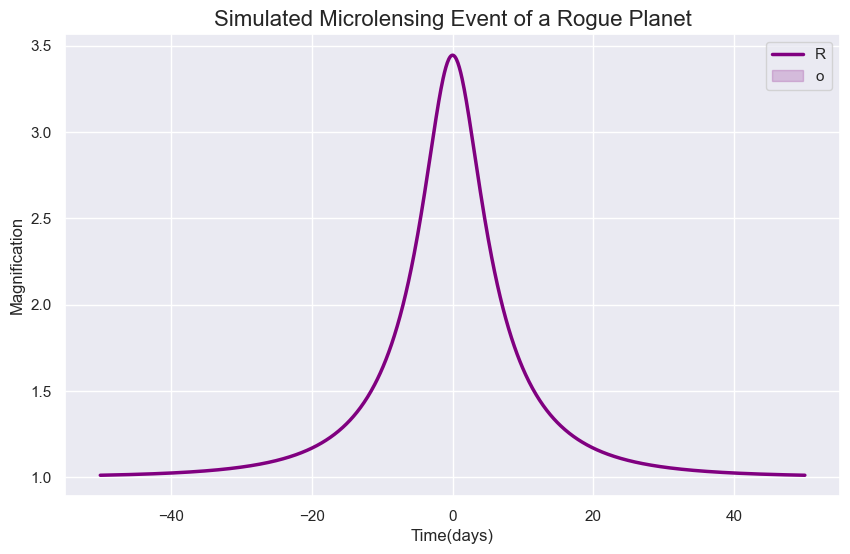

In [7]:
#Define the characteristics of our simulated rogue planet
peak_time = 0.0 # The exact day it hits maximum brightness
einstein_time = 15.0 # The duration of the event (relates to mass)
impact_param = 0.3  # How close it gets to "dead center" (0.0)
#This specific event will peak on day zero, it will last 15 days, and it will get relatively close to dead center.

magnification = paczynski_curve(time_array, peak_time, einstein_time, impact_param)

plt.figure(figsize=(10,6))
sns.lineplot(x=time_array, y=magnification, color="purple", linewidth=2.5)
plt.title("Simulated Microlensing Event of a Rogue Planet", fontsize=16)
plt.xlabel("Time(days)", fontsize=12)
plt.ylabel("Magnification",fontsize=12)
plt.legend(("Rogue Planet"), loc="upper right")
plt.show()

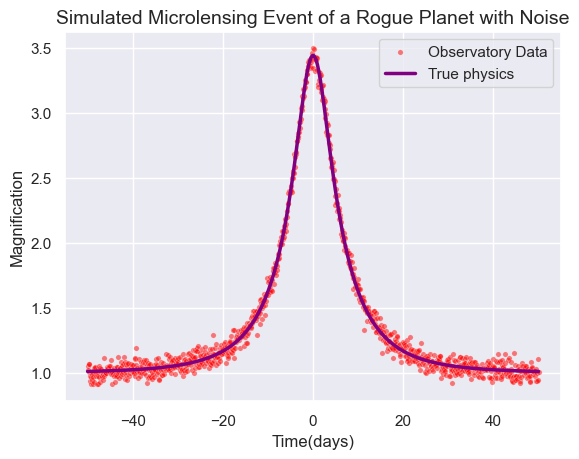

In [9]:
#Adding noise
noise_level = 0.05

#Adding random Gaussian Noise to the perfect curve
noisy_magnification = magnification + np.random.normal(0,noise_level,len(time_array))

#Plotting the noisy data
plt.figsize=(10,6)

sns.scatterplot(x=time_array, y=noisy_magnification, color="red", s=15, alpha=0.5, label="Observatory Data")
sns.lineplot(x=time_array, y=magnification, color="purple", linewidth=2.5, label="True physics")

plt.title("Simulated Microlensing Event of a Rogue Planet with Noise", fontsize=14)
plt.xlabel("Time(days)",fontsize=12)
plt.ylabel("Magnification",fontsize=12)
plt.legend(loc="upper right")
plt.show()

We are going to hide your perfect purple line, hand the computer only the messy black dots, and ask it: "Based on these dots, what was the mass and alignment of the rogue planet?"

In [10]:
from scipy.optimize import curve_fit
# 2. Give the computer a starting hint
# Our rough guesses for: [peak_time, einstein_time, impact_param]

initial_guesses=[0.1,10.0,0.5]

In [11]:
# popt: "Optimized Parameters" (The computer's final, best guesses)
# pcov: "Covariance" (How confident the computer is. We'll ignore this for now)

popt, pcov = curve_fit(paczynski_curve, time_array, noisy_magnification, p0=initial_guesses)

#Unpack final answers computer found
guessed_t0 = popt[0] # The guessed peak time
guessed_tE = popt[1] # The guessed Einstein duration
guessed_u0 = popt[2] # The guessed impact parameter

print(f"True Peak time:0.0 | Computer's guess: {guessed_t0:.3f}")
print(f"True Einstein duration:15.0 | Computer's guess: {guessed_tE:.3f}")
print(f"True impact parameter:0.3 | Computer's guess: {guessed_u0:.3f}")



True Peak time:0.0 | Computer's guess: -0.017
True Einstein duration:15.0 | Computer's guess: 15.112
True impact parameter:0.3 | Computer's guess: 0.301


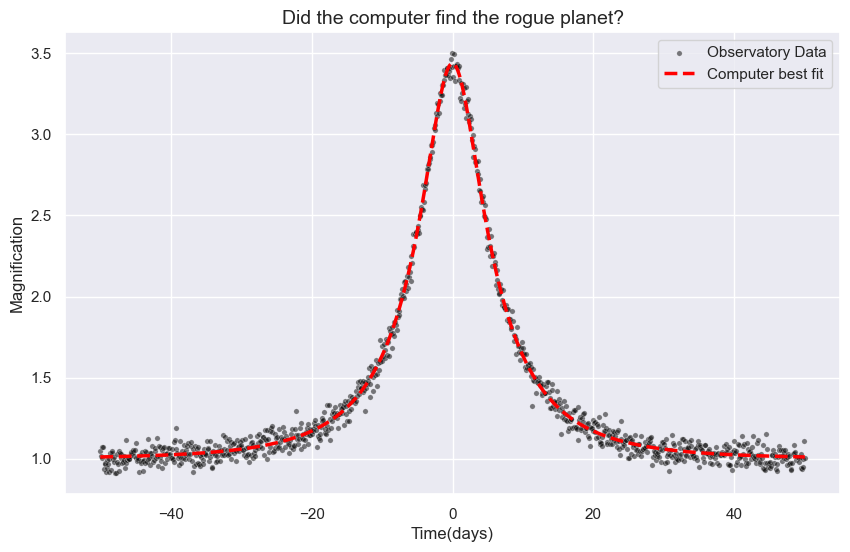

In [12]:
best_fit_magnification = paczynski_curve(time_array, guessed_t0, guessed_tE, guessed_u0)
plt.figure(figsize=(10,6))
sns.scatterplot(x=time_array,y=noisy_magnification, color="black", s=15, alpha=0.5, label="Observatory Data")
sns.lineplot(x=time_array, y=best_fit_magnification, color="red", linewidth=2.5, linestyle="--", label="Computer best fit")
plt.title("Did the computer find the rogue planet?", fontsize=14)
plt.xlabel("Time(days)",fontsize=12)
plt.ylabel("Magnification",fontsize=12)
plt.legend(loc="upper right")
plt.show()